In [1]:
"""
Patch labelling: clearcut vs not-clearcut, with skip option.
Focus: identify mechanical timber harvesting (geometric clearings, bare soil, complete removal).
Everything else = not-clearcut. Skip = unreadable/corrupt patches.
"""

import pandas as pd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, clear_output
import ipywidgets as widgets

# Load labelling subset
subset_df = pd.read_csv('../data/training/labelling_subset_final.csv')
patch_dir = Path('../data/training/patches')

# Initialize or load existing labels
labels_file = Path('../data/training/patch_labels.csv')
if labels_file.exists():
    labels_df = pd.read_csv(labels_file)
    print(f"Loaded existing labels: {len(labels_df)} patches already labelled")
else:
    labels_df = pd.DataFrame(columns=['patch_id', 'year', 'clearing_type'])
    print("Starting fresh labelling session")

# Classification types
CLEARING_TYPES = ['clearcut', 'not_clearcut', 'skip']

print(f"\nTotal patches to label: {len(subset_df)}")
print(f"Already labelled: {len(labels_df)}")
print(f"Remaining: {len(subset_df) - len(labels_df)}")
print("\nLabelling guide:")
print("  CLEARCUT: Timber harvesting coupe (geometric edges, bare soil, complete removal)")
print("  NOT CLEARCUT: Everything else (fire, roads, selective, ambiguous, false positives)")
print("  SKIP: Unreadable (cloud cover, data corruption, edge artifacts)")

Starting fresh labelling session

Total patches to label: 315
Already labelled: 0
Remaining: 315

Labelling guide:
  CLEARCUT: Timber harvesting coupe (geometric edges, bare soil, complete removal)
  NOT CLEARCUT: Everything else (fire, roads, selective, ambiguous, false positives)
  SKIP: Unreadable (cloud cover, data corruption, edge artifacts)


In [2]:
def calculate_suggested_label(patch_path):
    """
    Calculate NDVI drop and SWIR intensity to suggest a clearing type.
    Returns suggested label.
    """
    with rasterio.open(patch_path) as src:
        # Read bands: [B4=Red, B3=Green, B2=Blue, B8=NIR, B11=SWIR]
        bands = src.read()
        
        red = bands[0]
        nir = bands[3]
        swir = bands[4]
        
        # Calculate NDVI
        ndvi = (nir - red) / (nir + red + 1e-10)
        
        # Filter valid values
        valid_ndvi = ndvi[(~np.isnan(ndvi)) & (ndvi != 0)]
        valid_swir = swir[(~np.isnan(swir)) & (swir != 0)]
        
        if len(valid_ndvi) < 100 or len(valid_swir) < 100:
            return 'uncertain'
        
        mean_ndvi = np.mean(valid_ndvi)
        mean_swir = np.mean(valid_swir)
        
        # Simple heuristic
        if mean_swir > 1500:  # High SWIR suggests fire (raw DN values)
            return 'fire'
        elif mean_ndvi < 0.2:  # Very low NDVI suggests clearcut
            return 'clearcut'
        elif mean_ndvi < 0.4:  # Moderate NDVI suggests selective logging
            return 'selective_logging'
        else:
            return 'uncertain'

def display_patch(patch_id, year):
    """Display a patch with RGB and false-colour composites."""
    patch_filename = f"patch_{year}_{patch_id:04d}.tif"
    patch_path = patch_dir / patch_filename
    
    if not patch_path.exists():
        print(f"Patch not found: {patch_filename}")
        return None
    
    with rasterio.open(patch_path) as src:
        bands = src.read()
        
        def normalize_band(band):
            """Normalize using percentile stretch."""
            valid = band[~np.isnan(band) & (band > 0)]
            if len(valid) < 100:
                return np.zeros_like(band)
            p2, p98 = np.percentile(valid, [2, 98])
            stretched = (band - p2) / (p98 - p2)
            return np.clip(stretched, 0, 1)
        
        # RGB composite
        rgb = np.dstack([
            normalize_band(bands[0]),  # Red
            normalize_band(bands[1]),  # Green
            normalize_band(bands[2])   # Blue
        ])
        
        # False-colour composite (NIR, Red, Green)
        false_colour = np.dstack([
            normalize_band(bands[3]),  # NIR
            normalize_band(bands[0]),  # Red
            normalize_band(bands[1])   # Green
        ])
    
    # Get suggested label
    suggested_label = calculate_suggested_label(patch_path)
    
    # Display
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.imshow(rgb)
    ax1.set_title('RGB (Natural Colour)')
    ax1.axis('off')
    
    ax2.imshow(false_colour)
    ax2.set_title('False Colour (NIR-R-G)\nHealthy veg = bright red')
    ax2.axis('off')
    
    plt.suptitle(f"Patch {patch_id} (Year {year}) — Suggested: {suggested_label}")
    plt.tight_layout()
    plt.show()
    
    return suggested_label

print("Display functions loaded")

Display functions loaded


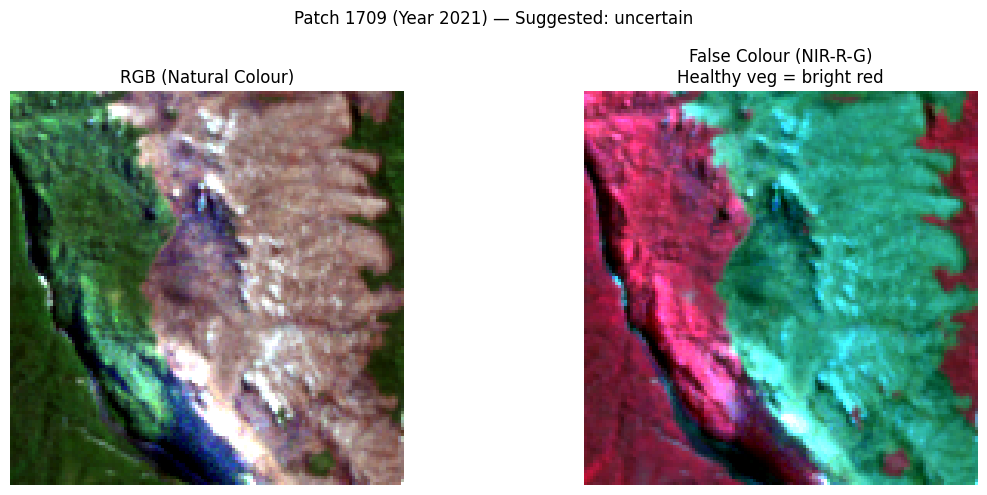

'uncertain'

In [3]:
# Test on first unlabelled patch
test_row = subset_df.iloc[0]
display_patch(int(test_row['id']), int(test_row['year']))

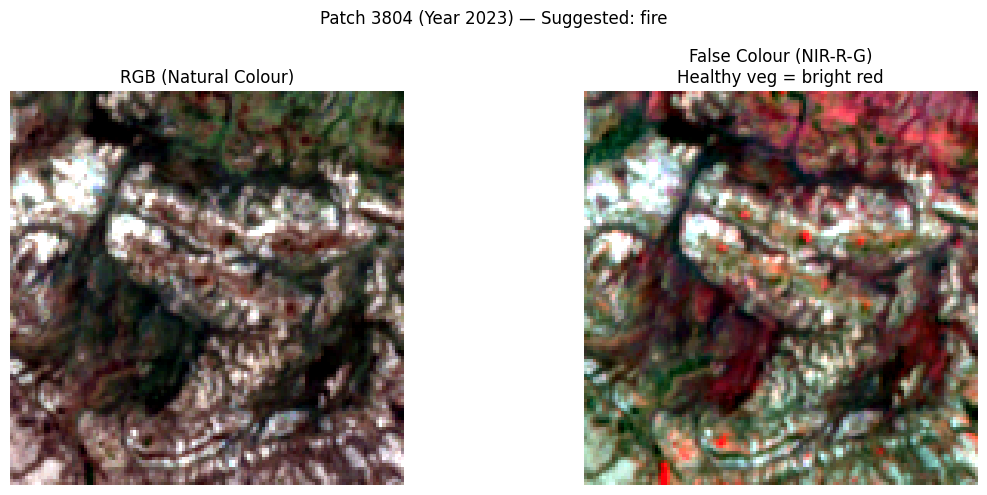

In [ ]:
# 3-button labelling interface

current_index = len(labels_df) if len(labels_df) > 0 else 0

def save_label(clearing_type):
    """Save label to CSV and move to next patch."""
    global current_index, labels_df
    
    if current_index >= len(subset_df):
        print("All patches labelled!")
        return
    
    row = subset_df.iloc[current_index]
    patch_id = int(row['id'])
    year = int(row['year'])
    
    # Add to labels dataframe
    new_label = pd.DataFrame([{
        'patch_id': patch_id,
        'year': year,
        'clearing_type': clearing_type
    }])
    labels_df = pd.concat([labels_df, new_label], ignore_index=True)
    
    # Save to CSV
    labels_df.to_csv('../data/training/patch_labels.csv', index=False)
    
    # Move to next patch
    current_index += 1
    
    # Display next patch
    clear_output(wait=True)
    if current_index < len(subset_df):
        print("="*60)
        print(f"PROGRESS: {current_index}/{len(subset_df)} patches labelled ({100*current_index/len(subset_df):.1f}%)")
        print(f"Last label: {clearing_type}")
        print("="*60)
        print()
        next_row = subset_df.iloc[current_index]
        suggested = display_patch(int(next_row['id']), int(next_row['year']))
        print(f"\nSuggested: {suggested}")
        print("\n👇 Click a button to label this patch:")
        display(widgets.HBox(buttons))
    else:
        print("="*60)
        print(f"✓ ALL {len(subset_df)} PATCHES LABELLED!")
        print("="*60)
        print(f"\nLabel distribution:")
        print(labels_df['clearing_type'].value_counts())

# Create 3 buttons
btn_clearcut = widgets.Button(
    description='CLEARCUT',
    button_style='success',
    layout=widgets.Layout(width='180px', height='50px')
)
btn_clearcut.on_click(lambda b: save_label('clearcut'))

btn_not = widgets.Button(
    description='NOT CLEARCUT',
    button_style='warning',
    layout=widgets.Layout(width='180px', height='50px')
)
btn_not.on_click(lambda b: save_label('not_clearcut'))

btn_skip = widgets.Button(
    description='SKIP',
    button_style='info',
    layout=widgets.Layout(width='180px', height='50px')
)
btn_skip.on_click(lambda b: save_label('skip'))

buttons = [btn_clearcut, btn_not, btn_skip]

# Display first patch
if current_index < len(subset_df):
    print(f"PROGRESS: {current_index}/{len(subset_df)}")
    row = subset_df.iloc[current_index]
    suggested = display_patch(int(row['id']), int(row['year']))
    print(f"\nSuggested: {suggested}")
    print("\n👇 Click a button to label this patch:")
    display(widgets.HBox(buttons))
else:
    print("All patches already labelled!")

In [7]:
len(labels_df)

315